In [20]:
import torch
from flonacomldft.utils.io_utils import (
    load_pickle_file, 
    get_project_path,
    load_csv_file
)
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data
from flonacomldft.sampling import run_metropolis
from flonacomldft.models.mixture import get_models
import numpy as np
import matplotlib.pyplot as plt

In [21]:
def load_dic(isomer, ID, i, deep_type):
    if isomer==0:
        name='planar'
    elif isomer==1:
        name='3d'

    dic = load_pickle_file('training/'+name+'/'+str(deep_type)+'s/results/is'+str(isomer)+'_'+str(deep_type)+'_dic_training_'+str(ID)+'_'+str(i)+'.pkl', 
                            path=get_project_path())
    
    return dic

In [22]:
def plot_losses(model_dic, init = 5000, split=100, ax=None, n_blocks=True):
    
    loss_train, loss_test = model_dic['losses']
    window_train = np.lib.stride_tricks.sliding_window_view(loss_train[init:], split)
    window_test = np.lib.stride_tricks.sliding_window_view(loss_test[init:], split)

    if ax==None:
        fig, ax = plt.subplots(1, 1)
    ax.plot(init+np.arange(len(loss_test[init:])), loss_train[init:], label = 'train')
    ax.plot(init+np.arange(len(loss_test[init:])), loss_test[init:], label = 'test')
    ax.plot(init+np.arange(window_train.mean(-1).shape[0]), window_train.mean(-1), label='average train window {:d}'.format(split))
    ax.plot(init+np.arange(window_test.mean(-1).shape[0]), window_test.mean(-1), label='average test window {:d}'.format(split))
    ax.plot(np.linspace(0, len(loss_train), 10), np.ones(10)*8/9*min(loss_test), 'o', label='models saved')
    #ax.set_yscale('log')
    ax.legend()
    ax.set_ylabel('loss')
    ax.set_xlabel('number iterations')
    if n_blocks:
        ax.set_title('mode label: {:d}, n blocks:{:d}, hidden dim: {:d}, hidden depth: {:d}'.format(model_dic['args']['mode_label'], model_dic['args']['n_blocks'], model_dic['args']['hidden_dim'], model_dic['args']['hidden_depth']));
    else:
        ax.set_title('mode label: {:d}, hidden dim: {:d}, hidden depth: {:d}'.format(model_dic['args']['mode_label'], model_dic['args']['hidden_dim'], model_dic['args']['hidden_depth']));

    return ax

In [23]:
def plot_ratios(model_dic, init = 0, split=100, ax=None):
    
    ratio = model_dic['ratios']
    window_ratio = np.lib.stride_tricks.sliding_window_view(ratio[init:], split)

    if ax==None:
        fig, ax = plt.subplots(1, 1)
    ax.plot(init+np.arange(len(ratio[init:])), ratio[init:], label = 'ratio')
    ax.plot(init+np.arange(window_ratio.mean(-1).shape[0]), window_ratio.mean(-1), label='average ratio window {:d}'.format(split))
    ax.plot(np.linspace(0, len(ratio), 10), np.ones(10)*8/9*min(ratio), 'o', label='models saved')
    #ax.set_yscale('log')
    ax.legend()
    ax.set_ylabel('ratios')
    ax.set_xlabel('number iterations')
    #ax.set_title('mode label: {:d}, n blocks:{:d}, hidden dim: {:d}, hidden depth: {:d}'.format(model_dic['args']['mode_label'], model_dic['args']['n_blocks'], model_dic['args']['hidden_dim'], model_dic['args']['hidden_depth']));
    
    return ax

In [24]:
# ========================= MH for several models =========================

In [25]:
ids_flow_0 = [2162933, 2162929, 2162929]
task_0 = [3, 3, 7]
ids_flow_1 = [2163112, 2163112, 2163119]
task_1 = [12, 15, 12]

ids_flow_0, ids_flow_1

([2162933, 2162929, 2162929], [2163112, 2163112, 2163119])

In [26]:
flows_0 = [load_dic(0, id_flow_0, i, 'flow') for i, id_flow_0 in zip(task_0, ids_flow_0)]

In [27]:
flows_1 = [load_dic(1, id_flow_1, i, 'flow') for i, id_flow_1 in zip(task_1, ids_flow_1)]

In [28]:
for flow in flows_0:
    print(flow['args'])

{'num_procs': 8, 'n_iter': 50000, 'learning_rate': 5e-05, 'mode_label': 0, 'n_blocks': 8, 'hidden_dim': 32, 'hidden_depth': 3, 'slurm_id': '2162933_3', 'date_start': '16:56:15 25-02-2023', 'random_seed': '44', 'date_end': '18:03:13 25-02-2023'}
{'num_procs': 8, 'n_iter': 50000, 'learning_rate': 5e-05, 'mode_label': 0, 'n_blocks': 4, 'hidden_dim': 32, 'hidden_depth': 3, 'slurm_id': '2162929_3', 'date_start': '16:56:03 25-02-2023', 'random_seed': '37', 'date_end': '17:40:28 25-02-2023'}
{'num_procs': 8, 'n_iter': 50000, 'learning_rate': 5e-05, 'mode_label': 0, 'n_blocks': 4, 'hidden_dim': 64, 'hidden_depth': 3, 'slurm_id': '2162929_7', 'date_start': '16:56:03 25-02-2023', 'random_seed': '93', 'date_end': '17:44:44 25-02-2023'}


In [29]:
for flow in flows_1:
    print(flow['args'])

{'num_procs': 8, 'n_iter': 50000, 'learning_rate': 5e-05, 'mode_label': 1, 'n_blocks': 4, 'hidden_dim': 104, 'hidden_depth': 4, 'slurm_id': '2163112_12', 'date_start': '19:09:50 25-02-2023', 'random_seed': '82', 'date_end': '20:58:19 25-02-2023'}
{'num_procs': 8, 'n_iter': 50000, 'learning_rate': 5e-05, 'mode_label': 1, 'n_blocks': 4, 'hidden_dim': 128, 'hidden_depth': 4, 'slurm_id': '2163112_15', 'date_start': '19:59:26 25-02-2023', 'random_seed': '0', 'date_end': '22:05:03 25-02-2023'}
{'num_procs': 8, 'n_iter': 50000, 'learning_rate': 5e-05, 'mode_label': 1, 'n_blocks': 12, 'hidden_dim': 104, 'hidden_depth': 3, 'slurm_id': '2163119_12', 'date_start': '19:11:08 25-02-2023', 'random_seed': '87', 'date_end': '21:25:24 25-02-2023'}


In [30]:
coord_mapping = Coordinates_mapping()

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51

In [31]:
mlps_dic = [load_pickle_file('models/is{:d}_mlp_dic_training.pkl'.format(mode_label)) for mode_label in [0, 1]]
mlps = get_models(mlps_dic)

In [32]:
list(range(0,10))[::3]

[0, 3, 6, 9]

acc: 0.06: 100%|██████████| 250/250 [00:05<00:00, 43.96it/s]


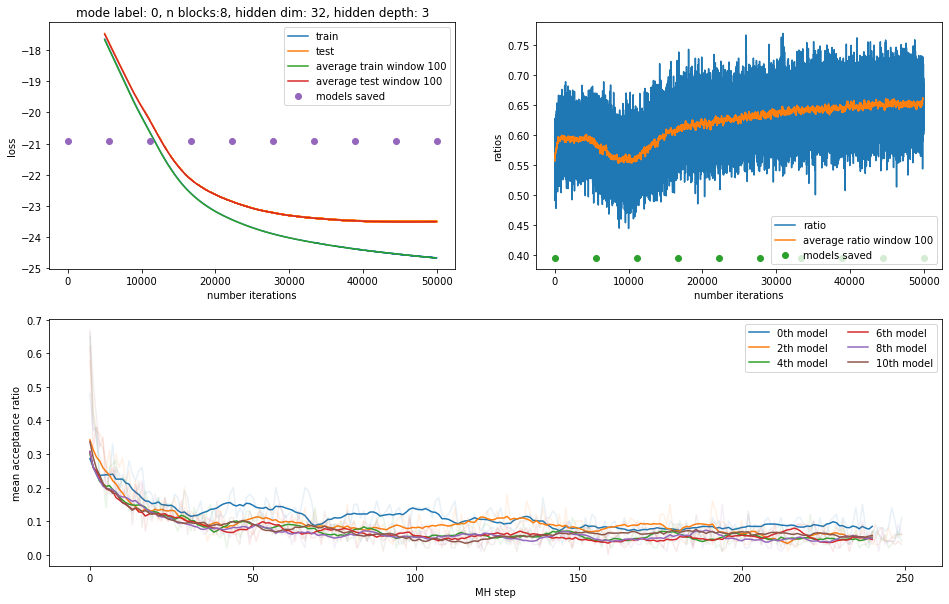

acc: 0.03: 100%|██████████| 250/250 [00:03<00:00, 64.81it/s]


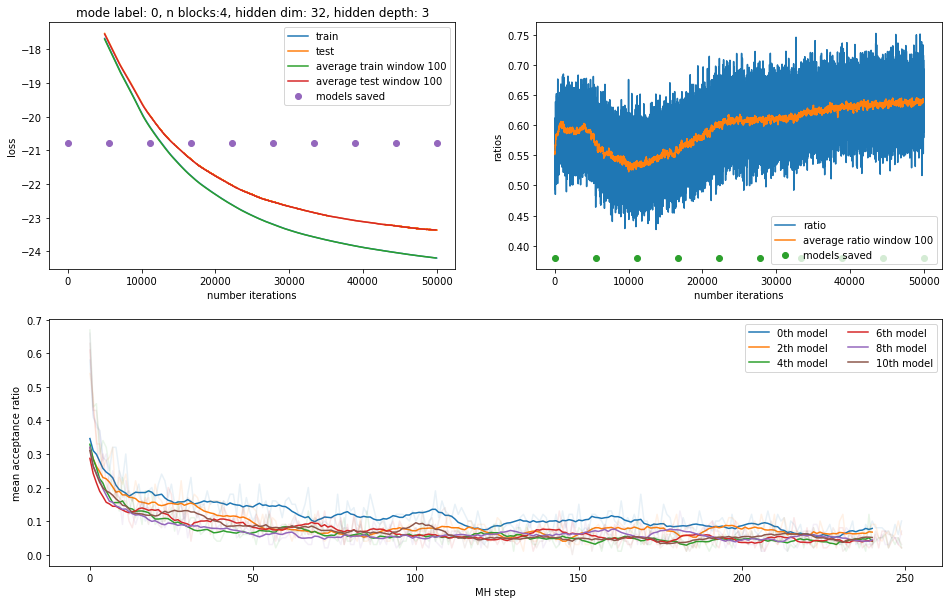

acc: 0.02: 100%|██████████| 250/250 [00:03<00:00, 68.62it/s]


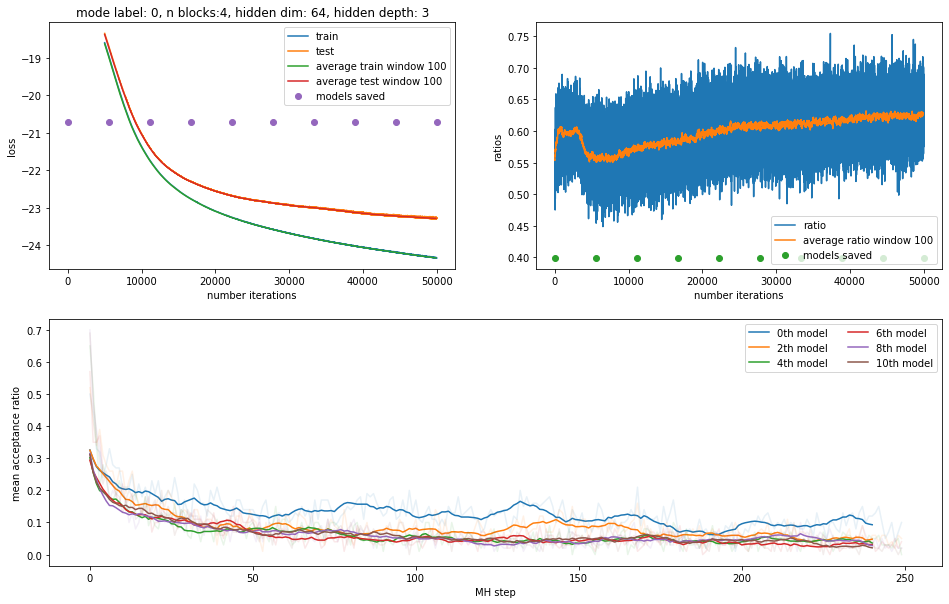

acc: 0.07: 100%|██████████| 250/250 [00:04<00:00, 51.76it/s]


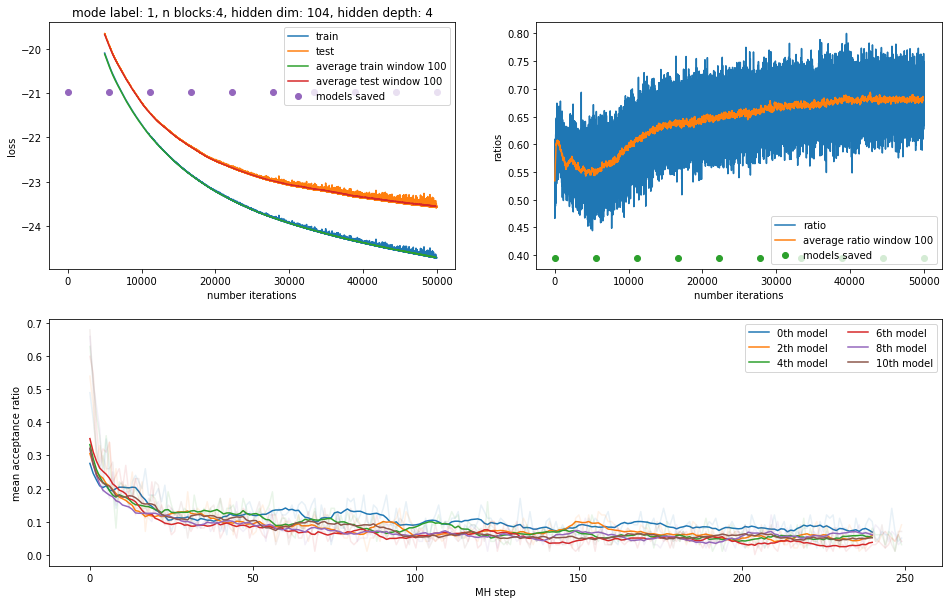

acc: 0.03: 100%|██████████| 250/250 [00:05<00:00, 49.27it/s]


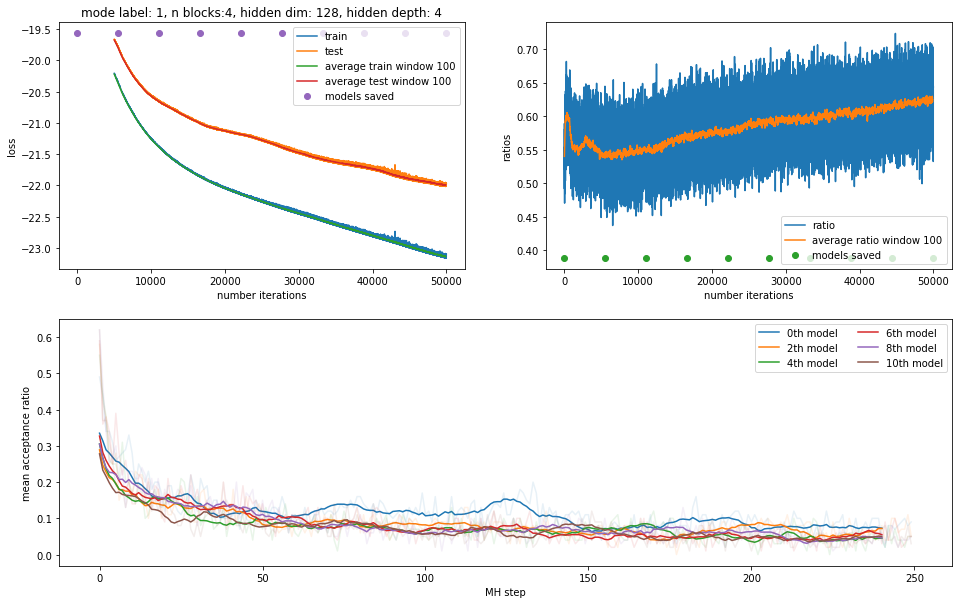

acc: 0.07: 100%|██████████| 250/250 [00:09<00:00, 27.68it/s]


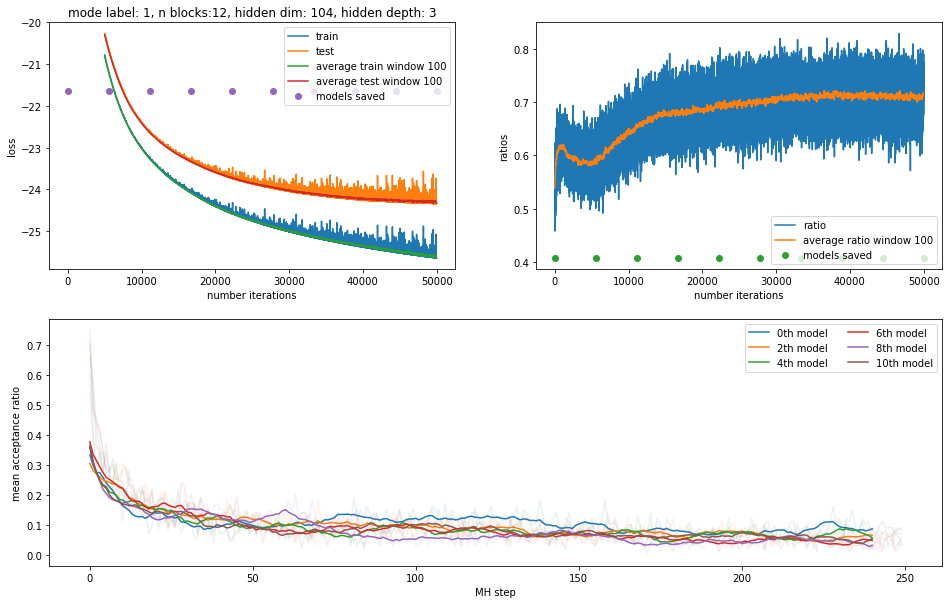

In [60]:
flows_dic = flows_0 + flows_1
for flow_dic in flows_dic:
    mcmc_runs = []
    #plt.figure(figsize=(12,5))
    fig = plt.figure(figsize=(16, 10))
    ax1 = plt.subplot(2,1,2)
    ax2 = plt.subplot(2,2,1)
    ax3 = plt.subplot(2,2,2)
    plot_losses(flow_dic, ax=ax2)
    plot_ratios(flow_dic, ax=ax3)
    
    for flow in flow_dic['models'][::2]:
        mode_label = flow_dic['args']['mode_label']
        zmat_test = load_csv_file("datasets/is{:d}_md_test.csv".format(mode_label))

        xs_test, logdetjacs_test, energies_test = coord_mapping.get_real_centered_from_internal(
                                            zmat_test[:, :12],
                                            isomer=mode_label,
                                            energies=zmat_test[:, 12],
                                            logdetjacs=zmat_test[:, 14],
                                            )
        xs_test = xs_test.to(torch.float32)
        test = join_data(xs_test,
                        energies_test,
                        zmat_test[:, 13],
                        logdetjacs_test,
        )

        n_chains = 100
        init = test[:n_chains]
        mcmc_run = run_metropolis(flow, init, init.shape[0], n_steps=250, energy_type='mlp', mlp_models=mlps[mode_label], with_tqdm=True)
        mcmc_runs.append(mcmc_run)
    
    for d,mcmc_run in enumerate(mcmc_runs):
        _ = ax1.plot((mcmc_run['accs'] * 1.).mean(1), alpha=0.1)
        ax1.plot(moving_average((mcmc_run['accs'] * 1.).mean(1), 10), c=_[0].get_color(), label='{:d}th model'.format(d*2))
    ax1.set_xlabel('MH step')
    ax1.set_ylabel('mean acceptance ratio')
    ax1.legend(ncol=2)
    plt.show()

In [57]:
# DFT ratio

In [58]:
isomer = 0; ID = [2166826, 2167003] 

dic_2 = load_pickle_file('training/dft_vs_mlp_ratio/dft_2/is'+str(isomer)+'_flow_dic_training_'+str(ID[0])+'_.pkl', 
                            path=get_project_path())
dic_3 = load_pickle_file('training/dft_vs_mlp_ratio/dft_3/is'+str(isomer)+'_flow_dic_training_'+str(ID[1])+'_.pkl', 
                            path=get_project_path())


Text(0, 0.5, 'acceptance ratio')

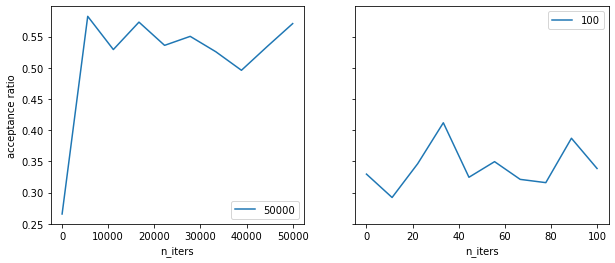

In [63]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axs[1].plot(np.linspace(0, dic_2['args']['n_iter'], 10), dic_2['ratios'], label=dic_2['args']['n_iter'])
axs[0].plot(np.linspace(0, dic_3['args']['n_iter'], 10), dic_3['ratios'], label=dic_3['args']['n_iter'])
axs[0].legend()
axs[1].legend()
axs[0].set_xlabel('n_iters')
axs[1].set_xlabel('n_iters')
axs[0].set_ylabel('acceptance ratio')